# GPA Analyzer & Predictor

### A Python-Based Student Academic Performance Analysis System

This project analyzes student academic results using Python and Pandas. It calculates semester GPA and cumulative GPA (CGPA), visualizes academic performance across semesters, provides "What-If" CGPA scenarios, calculates the GPA required to reach a target CGPA, and uses a simple Linear Regression model to predict future GPA performance.

### Technologies Used

- Python
- Pandas
- Matplotlib
- Scikit-learn
- Jupyter Notebook

### Project Objectives

1. Calculate semester GPA and overall CGPA.
2. Analyze academic performance across semesters.
3. Visualize GPA trends using graphs.
4. Allow students to test possible future GPA scenarios.
5. Calculate the GPA required to achieve a target CGPA.
6. Provide simple performance insights.
7. Predict future GPA using historical academic performance.
8. Handle missing and invalid data appropriately.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

print("GPA Analyzer & Predictor")
print("Project started successfully!")

GPA Analyzer & Predictor
Project started successfully!


In [3]:
# Load the student results
data = pd.read_csv("results.csv")

# Display the results
print("Student Results:")
display(data)

Student Results:


,semester,course,units,grade
0,1,Mathematics,3,A
1,1,Programming,3,B
2,1,Physics,2,C
3,1,English,2,A
4,1,Computer Fundamentals,3,B
5,2,Database Systems,3,B
6,2,Statistics,3,A
7,2,Web Development,3,B
8,2,Software Engineering,3,A
9,2,Computer Networks,2,B


In [4]:
# Convert grades to grade points

grade_points = {
    "A": 5,
    "B": 4,
    "C": 3,
    "D": 2,
    "E": 1,
    "F": 0
}

data["grade_point"] = data["grade"].map(grade_points)

display(data)

,semester,course,units,grade,grade_point
0,1,Mathematics,3,A,5
1,1,Programming,3,B,4
2,1,Physics,2,C,3
3,1,English,2,A,5
4,1,Computer Fundamentals,3,B,4
5,2,Database Systems,3,B,4
6,2,Statistics,3,A,5
7,2,Web Development,3,B,4
8,2,Software Engineering,3,A,5
9,2,Computer Networks,2,B,4


In [5]:
# Calculate quality points for each course

data["quality_points"] = data["units"] * data["grade_point"]

display(data)


,semester,course,units,grade,grade_point,quality_points
0,1,Mathematics,3,A,5,15
1,1,Programming,3,B,4,12
2,1,Physics,2,C,3,6
3,1,English,2,A,5,10
4,1,Computer Fundamentals,3,B,4,12
5,2,Database Systems,3,B,4,12
6,2,Statistics,3,A,5,15
7,2,Web Development,3,B,4,12
8,2,Software Engineering,3,A,5,15
9,2,Computer Networks,2,B,4,8


## Semester GPA Analysis

The table below shows the total credit units, total quality points, and GPA for each semester.

In [6]:
# Calculate GPA for each semester

semester_gpa = data.groupby("semester").agg(
    total_units=("units", "sum"),
    total_quality_points=("quality_points", "sum")
)

semester_gpa["GPA"] = (
    semester_gpa["total_quality_points"] /
    semester_gpa["total_units"]
)

semester_summary = semester_gpa.copy()
semester_summary["GPA"] = semester_summary["GPA"].round(2)

display(semester_summary)

,total_units,total_quality_points,GPA
semester,,,
1,13,55,4.23
2,14,62,4.43
3,15,69,4.60
4,14,64,4.57


## Overall CGPA

In [7]:
# Calculate overall CGPA

total_units = data["units"].sum()
total_quality_points = data["quality_points"].sum()

cgpa = total_quality_points / total_units

print(f"Total Units: {total_units}")
print(f"Total Quality Points: {total_quality_points}")
print(f"Current CGPA: {cgpa:.2f}")

Total Units: 56
Total Quality Points: 250
Current CGPA: 4.46


In [8]:
# Check for missing values

print("Missing Values:")
print(data.isnull().sum())


Missing Values:
semester          0
course            0
units             0
grade             0
grade_point       0
quality_points    0
dtype: int64


In [9]:
# Check for invalid grades

valid_grades = ["A", "B", "C", "D", "E", "F"]

invalid_grades = data[~data["grade"].isin(valid_grades)]

if len(invalid_grades) > 0:
    print("Invalid grades found:")
    display(invalid_grades)
else:
    print("✓ All grades are valid.")


# Check for invalid units

invalid_units = data[data["units"] <= 0]

if len(invalid_units) > 0:
    print("Invalid units found:")
    display(invalid_units)
else:
    print("✓ All course units are valid.")

✓ All grades are valid.
✓ All course units are valid.


## GPA Trend Visualization

The line graph below shows how the student's GPA has changed across semesters.

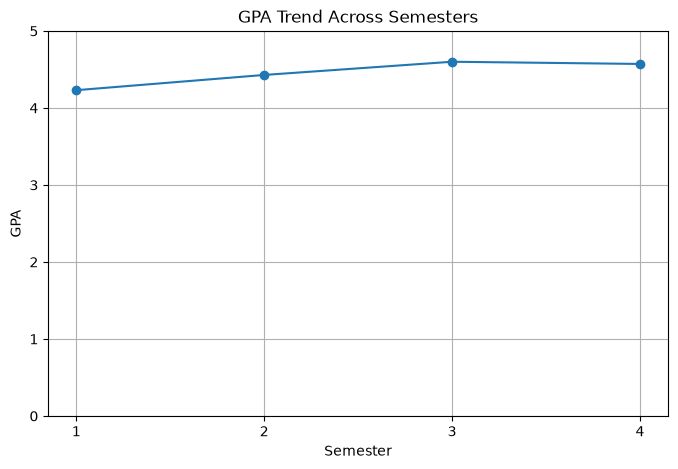

In [10]:
# Plot GPA across semesters

plt.figure(figsize=(8, 5))

plt.plot(
    semester_gpa.index,
    semester_gpa["GPA"],
    marker="o"
)

plt.title("GPA Trend Across Semesters")
plt.xlabel("Semester")
plt.ylabel("GPA")
plt.xticks(semester_gpa.index)
plt.ylim(0, 5)
plt.grid(True)

plt.show()

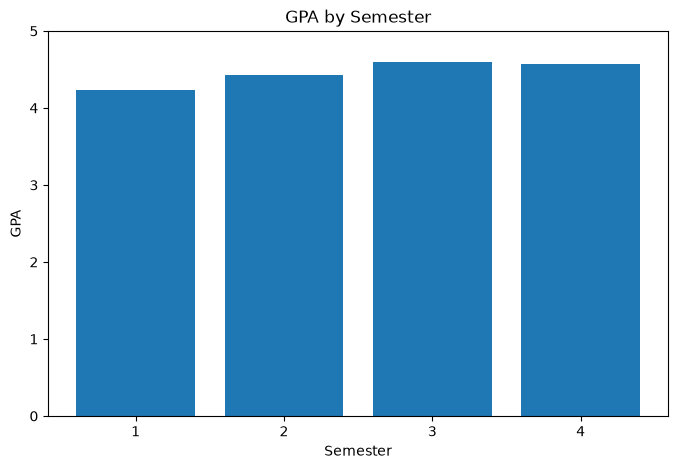

In [11]:
# Bar chart of semester GPA

plt.figure(figsize=(8, 5))

plt.bar(
    semester_gpa.index,
    semester_gpa["GPA"]
)

plt.title("GPA by Semester")
plt.xlabel("Semester")
plt.ylabel("GPA")
plt.xticks(semester_gpa.index)
plt.ylim(0, 5)

plt.show()

## What-If CGPA Calculator

This tool allows a student to estimate their future CGPA based on an expected GPA and the number of credit units they plan to take in the next semester.

In [12]:
# What-If CGPA Calculator

print("===== WHAT-IF CGPA CALCULATOR =====")

next_semester_gpa = float(
    input("Enter expected GPA for next semester (0-5): ")
)

next_semester_units = int(
    input("Enter expected credit units: ")
)

if 0 <= next_semester_gpa <= 5 and next_semester_units > 0:

    projected_quality_points = (
        next_semester_gpa * next_semester_units
    )

    projected_total_quality_points = (
        total_quality_points + projected_quality_points
    )

    projected_total_units = (
        total_units + next_semester_units
    )

    projected_cgpa = (
        projected_total_quality_points /
        projected_total_units
    )

    print("\n===== RESULT =====")
    print(f"Current CGPA: {cgpa:.2f}")
    print(f"Expected GPA: {next_semester_gpa:.2f}")
    print(f"Expected Units: {next_semester_units}")
    print(f"Projected CGPA: {projected_cgpa:.2f}")

    if projected_cgpa > cgpa:
        print("📈 Your CGPA is expected to improve.")
    elif projected_cgpa < cgpa:
        print("📉 Your CGPA is expected to decrease.")
    else:
        print("➡️ Your CGPA is expected to remain the same.")

else:
    print(
        "Invalid input. GPA must be between 0 and 5, "
        "and credit units must be greater than 0."
    )

===== WHAT-IF CGPA CALCULATOR =====



===== RESULT =====
Current CGPA: 4.46
Expected GPA: 4.50
Expected Units: 15
Projected CGPA: 4.47
📈 Your CGPA is expected to improve.


## Path to Target CGPA

This tool calculates the GPA a student needs in the next semester to reach a desired CGPA.

In [13]:
# Target CGPA Calculator

target_cgpa = float(input("Enter your target CGPA (0-5): "))
next_semester_units = int(input("Enter your next semester units: "))

if 0 <= target_cgpa <= 5 and next_semester_units > 0:

    required_quality_points = (
        target_cgpa * (total_units + next_semester_units)
    ) - total_quality_points

    required_gpa = required_quality_points / next_semester_units

    print(f"\nCurrent CGPA: {cgpa:.2f}")
    print(f"Target CGPA: {target_cgpa:.2f}")
    print(f"Required GPA next semester: {required_gpa:.2f}")

    if required_gpa > 5:
        print("⚠️ This target cannot be reached in one semester.")
    elif required_gpa <= 0:
        print("🎉 You have already reached or exceeded this target.")
    else:
        print("✓ This target is achievable if you maintain the required GPA.")

else:
    print("Invalid input. Target CGPA must be between 0 and 5, and units must be greater than 0.")


Current CGPA: 4.46
Target CGPA: 4.70
Required GPA next semester: 5.64
⚠️ This target cannot be reached in one semester.


In [14]:
# Generate performance insights

first_gpa = semester_gpa["GPA"].iloc[0]
last_gpa = semester_gpa["GPA"].iloc[-1]

print("===== PERFORMANCE INSIGHT =====")

if last_gpa > first_gpa:
    print("📈 Your GPA has improved since your first semester.")
elif last_gpa < first_gpa:
    print("📉 Your GPA has decreased since your first semester.")
else:
    print("➡️ Your GPA has remained relatively stable.")

if last_gpa >= 4.5:
    print("🌟 Excellent performance! Keep maintaining your current level.")
elif last_gpa >= 3.5:
    print("👍 Good performance. Continue working to improve your GPA.")
elif last_gpa >= 2.5:
    print("⚠️ Your performance is average. Consider focusing more on your weaker courses.")
else:
    print("⚠️ Your GPA needs improvement. Consider creating a study plan.")

===== PERFORMANCE INSIGHT =====
📈 Your GPA has improved since your first semester.
🌟 Excellent performance! Keep maintaining your current level.


## AI-Based GPA Prediction

A simple Linear Regression model is used to analyze previous semester GPAs and predict the student's GPA for the next semester.

In [15]:
# AI-Based GPA Prediction

from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare historical GPA data
X = semester_gpa.index.values.reshape(-1, 1)
y = semester_gpa["GPA"].values

# Create and train the model
model = LinearRegression()
model.fit(X, y)

# Predict the next semester GPA
next_semester = np.array([[semester_gpa.index.max() + 1]])
predicted_gpa = model.predict(next_semester)[0]

# Keep the prediction within the valid GPA range
predicted_gpa = max(0, min(5, predicted_gpa))

print("===== GPA PREDICTION =====")
print(f"Predicted GPA for next semester: {predicted_gpa:.2f}")

===== GPA PREDICTION =====
Predicted GPA for next semester: 4.76


## Predicted Future CGPA

The predicted GPA is combined with the student's current academic results to estimate the CGPA after the next semester.

In [16]:
# Predict future CGPA

predicted_units = int(input("Enter expected units for next semester: "))

if predicted_units > 0:

    predicted_quality_points = predicted_gpa * predicted_units

    predicted_cgpa = (
        total_quality_points + predicted_quality_points
    ) / (total_units + predicted_units)

    print("\n===== FINAL CGPA PREDICTION =====")
    print(f"Current CGPA: {cgpa:.2f}")
    print(f"Predicted Next Semester GPA: {predicted_gpa:.2f}")
    print(f"Predicted CGPA: {predicted_cgpa:.2f}")

else:
    print("Invalid input. Units must be greater than 0.")


===== FINAL CGPA PREDICTION =====
Current CGPA: 4.46
Predicted Next Semester GPA: 4.76
Predicted CGPA: 4.53
